(np.float64(-0.5), np.float64(1264.5), np.float64(1286.5), np.float64(-0.5))

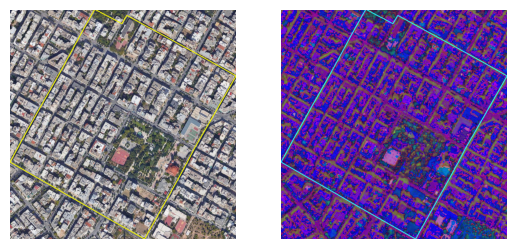

In [2]:
import cv2
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
image = cv2.imread('../data/images/overlays/fid_geitonies_35_overlay.png')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
plt.imshow(hsv)
plt.axis('off')

(np.float64(-0.5), np.float64(1264.5), np.float64(1286.5), np.float64(-0.5))

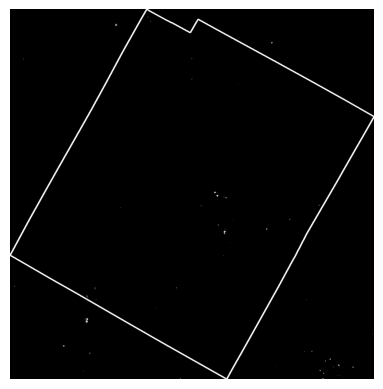

In [3]:
import numpy as np

lower_yellow = np.array([18, 120, 120])
upper_yellow = np.array([38, 255, 255])
yellow_px = cv2.inRange(hsv, lower_yellow, upper_yellow)

plt.imshow(yellow_px, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(1264.5), np.float64(1286.5), np.float64(-0.5))

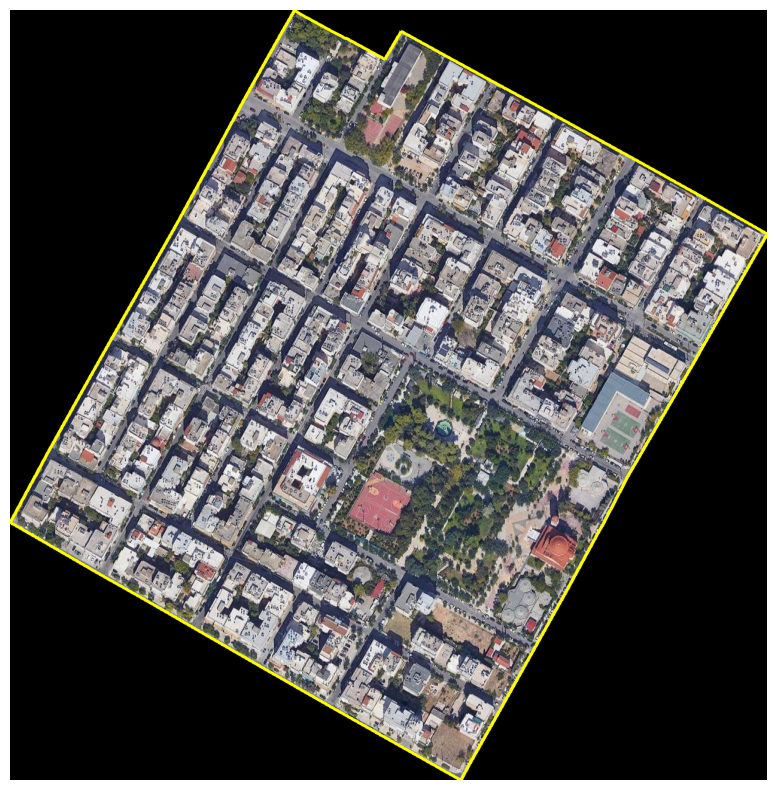

In [4]:
contours, _ = cv2.findContours(
    yellow_px, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

largest = max(contours, key=cv2.contourArea)
area = cv2.contourArea(largest)
img_area = image.shape[0] * image.shape[1]

mask = np.zeros(image.shape[:2], dtype=np.uint8)
cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)

fig = plt.figure(figsize=(12, 10))

masked_image = cv2.bitwise_and(image, image, mask=mask)
plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [5]:
r = masked_image[:, :, 0].astype(np.float32)
g = masked_image[:, :, 1].astype(np.float32)
b = masked_image[:, :, 2].astype(np.float32)
X = np.column_stack((r.flatten(), g.flatten(), b.flatten()))

hsv = cv2.cvtColor(masked_image, cv2.COLOR_BGR2HSV)
h = hsv[:, :, 0].flatten()
s = hsv[:, :, 1].flatten()
v = hsv[:, :, 2].flatten()
X_hsv = np.column_stack((h, s, v))
# plt.scatter(r.flatten(), g.flatten(), c=g, alpha=0.1)

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0).fit(X)
labels = kmeans.labels_

# plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.1)

(np.float64(-0.5), np.float64(1264.5), np.float64(1286.5), np.float64(-0.5))

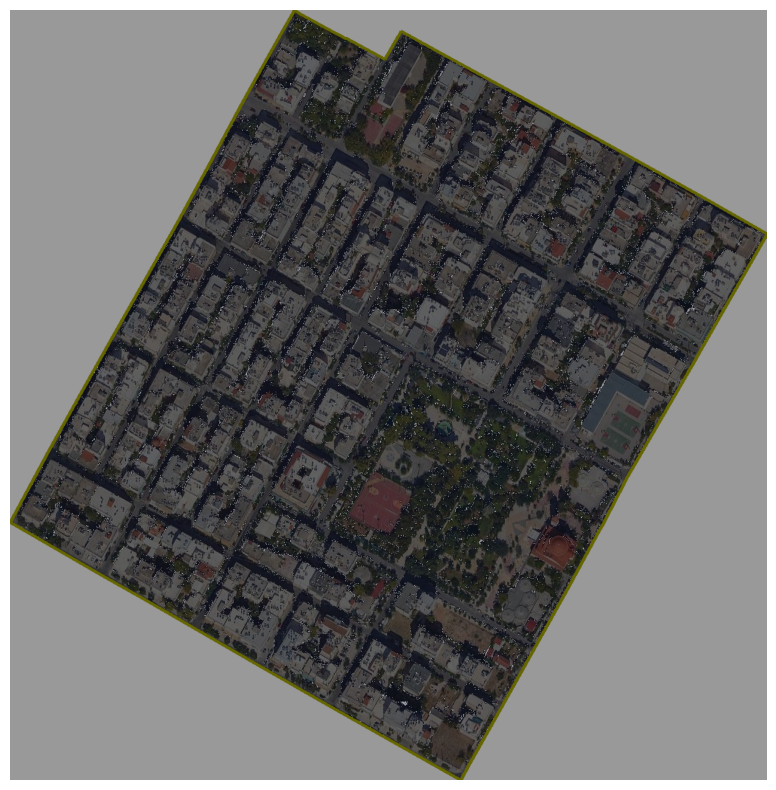

In [14]:
fig = plt.figure(figsize=(12, 10))
plt.imshow(cv2.addWeighted(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB), 0.4, cv2.cvtColor(np.array([labels == 0], dtype=np.uint8).reshape(*masked_image.shape[:2]) * 255, cv2.COLOR_GRAY2RGB), 0.6, 0))
plt.axis('off')

In [8]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# 1. Define KernelPCA to project and reduce data
kpca = PCA(n_components=2)

# 2. Define K-Means
kmeans = KMeans(n_clusters=5, random_state=42)

# 3. Chain together
pipeline = make_pipeline(kpca, kmeans)

# 4. Fit the model to your data
model = pipeline.fit(X)
labels = model.named_steps['kmeans'].labels_

(np.float64(-0.5), np.float64(1264.5), np.float64(1286.5), np.float64(-0.5))

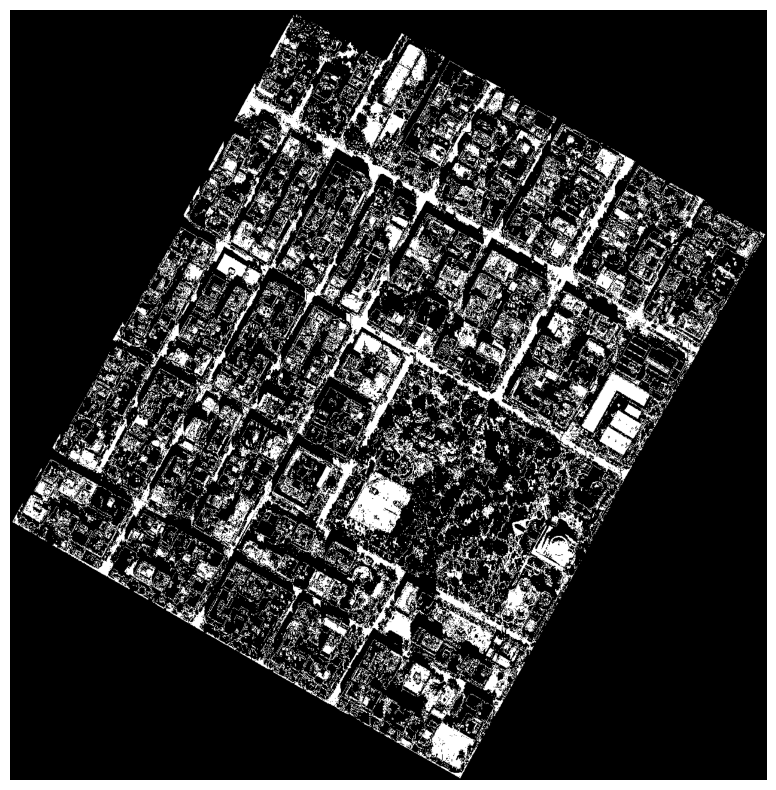

In [17]:
fig = plt.figure(figsize=(12, 10))
plt.imshow(cv2.addWeighted(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB), 0, cv2.cvtColor(np.array([labels == 2], dtype=np.uint8).reshape(*masked_image.shape[:2]) * 255, cv2.COLOR_GRAY2RGB), 1, 0))
plt.axis('off')